# Persistent Homology Analysis of Fire Station Coverage in LA County
## Research: Identifying Vulnerable Neighborhoods During Natural Disasters (Wildfires)

**Method:** Persistent Homology via Vietoris-Rips Complex (primary) + Witness Complex (validation)  
**Libraries:** `gudhi`, `geopandas`, `numpy`, `scipy`, `pyproj`, `matplotlib`

### Topological Interpretation
| Feature | Meaning |
|---|---|
| **H0** (connected components) | Long-lived bar → isolated station cluster far from others → sparse coverage zone |
| **H1** (1-cycles / loops) | Long-lived bar → topological void: stations encircle a region with none inside → coverage gap |

### Pipeline
1. Install dependencies  
2. Configuration & imports  
3. Load & inspect data  
4. Clip stations to LA County boundary  
5. Project to UTM 11N (metres)  
6. Vietoris-Rips Persistent Homology  
7. Witness Complex Persistent Homology  
8. Persistence statistics  
9. Betti numbers at operational radii  
10. Significant H1 void detection  
11. Spatial localisation of voids → neighborhoods  
12. Neighborhood vulnerability scoring  
13. Visualisation (persistence diagram, barcodes, choropleth map)  
14. Export results

## Step 1 — Install Dependencies

In [78]:
# Run once; restart kernel afterwards if installing for the first time
# %pip install gudhi geopandas pyproj shapely scipy matplotlib pandas

## Step 2 — Imports & Configuration

All tuneable parameters are collected here so they are easy to adjust without hunting through the code.

In [79]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import geopandas as gpd
import gudhi
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial.distance import pdist, squareform, cdist
from pyproj import Transformer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Paths (adjust if your files are in a different directory) ──
STATIONS_PATH  = "../../data/all_stations.geojson"
LA_COUNTY_PATH = "../../data/la_county.geojson"

# ── Filtration parameters ──
RIPS_MAX_M          = 25_000   # 25 km — maximum Rips edge length
N_LANDMARKS         = 80       # ~20 % of stations used as Witness landmarks
H1_SIG_THRESHOLD_M  = 3_000   # 3 km min persistence to call H1 void "significant"

# ── Operational evaluation radii (km → converted to m below) ──
# Based on NFPA 1710 (urban) and wildfire staging distances
EVAL_RADII_KM = [2, 4, 6, 8, 10, 15, 20]
EVAL_RADII_M  = [r * 1000 for r in EVAL_RADII_KM]

# ── Neighborhood vulnerability weights ──
W_DIST    = 0.50   # weight: min distance to nearest station
W_BETA1   = 0.30   # weight: local H1 count
W_DENSITY = 0.20   # weight: (1 - normalised station density)

# ── Coordinate reference systems ──
CRS_WGS84 = "EPSG:4326"    # input: WGS84 lon/lat
CRS_UTM   = "EPSG:32611"   # projected: UTM Zone 11N (LA County)

print("Imports OK — all packages loaded.")

Imports OK — all packages loaded.


## Step 3 — Load & Inspect Data

We load two datasets:
- **`all_stations.geojson`** — 412 fire station points (LAFD, LACoFD, municipal)
- **`la_county.geojson`** — 272 named neighborhood polygons covering LA County

In [80]:
# ── Load fire stations ──
stations_wgs = gpd.read_file("../../data/all_stations.geojson").set_crs(CRS_WGS84, allow_override=True)

print(f"Stations loaded : {len(stations_wgs)}")
print(f"  LAFD          : {(stations_wgs['department'] == 'LAFD').sum()}")
print(f"  LACoFD        : {(stations_wgs['department'] == 'LACoFD').sum()}")
print(f"  Other         : {(~stations_wgs['department'].isin(['LAFD','LACoFD'])).sum()}")
print()
stations_wgs.head(3)

Stations loaded : 412
  LAFD          : 106
  LACoFD        : 172
  Other         : 134



,address,city,zip,department,stanum,geometry
0,2759 Rowena Avenue,Los Angeles,90039,LAFD,56,POINT (-118.26386 34.10765)
1,135 South Fair Oaks Avenue,Pasadena,91105,Pasadena Fire Department,31,POINT (-118.15073 34.14318)
2,3361 Palo Verde Avenue,Long Beach,90808,Long Beach Fire Department,18,POINT (-118.10821 33.81822)


In [81]:
# ── Load LA County neighborhoods ──
county_wgs = gpd.read_file("../../data/la_county.geojson").set_crs(CRS_WGS84, allow_override=True)

print(f"Neighborhoods loaded : {len(county_wgs)}")
print(f"Geometry types       : {county_wgs.geometry.geom_type.unique()}")
print()
county_wgs.head(3)

Neighborhoods loaded : 272
Geometry types       : <ArrowStringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str



,name,slug,geometry
0,Acton,acton,"POLYGON ((-118.20262 34.53899, -118.18947 34.5..."
1,Adams-Normandie,adams-normandie,"POLYGON ((-118.30901 34.03741, -118.29151 34.0..."
2,Agoura Hills,agoura-hills,"POLYGON ((-118.76192 34.1682, -118.72632 34.16..."


## Step 4 — Clip Stations to LA County Boundary

Some stations in the raw dataset may fall just outside the county boundary. We keep only those geometrically within the county union.

In [82]:
county_boundary = unary_union(county_wgs.geometry)
within_mask     = stations_wgs.geometry.within(county_boundary)
stations_clipped = stations_wgs[within_mask].copy().reset_index(drop=True)

print(f"Stations before clip : {len(stations_wgs)}")
print(f"Stations after clip  : {len(stations_clipped)}")
print(f"Removed              : {len(stations_wgs) - len(stations_clipped)}")

Stations before clip : 412
Stations after clip  : 408
Removed              : 4


## Step 5 — Project to UTM Zone 11N (metres)

Persistent homology filtration is based on **Euclidean distance**. Projecting from lon/lat (degrees) to UTM metres ensures distances are meaningful and uniform across the county. UTM Zone 11N (EPSG:32611) is the standard projection for the Los Angeles region.

In [83]:
stations_proj = stations_clipped.to_crs(CRS_UTM)
county_proj   = county_wgs.to_crs(CRS_UTM)

# Extract (N, 2) coordinate array — this is our TDA point cloud
coords_m = np.column_stack([stations_proj.geometry.x,
                             stations_proj.geometry.y])

ext = coords_m.max(0) - coords_m.min(0)
print(f"Point cloud shape : {coords_m.shape}")
print(f"Spatial extent    : {ext[0]/1000:.1f} km (E–W)  ×  {ext[1]/1000:.1f} km (N–S)")
print(f"Centroid (UTM)    : {coords_m.mean(0).astype(int)}")

Point cloud shape : (408, 2)
Spatial extent    : 108.6 km (E–W)  ×  116.3 km (N–S)
Centroid (UTM)    : [ 385237 3771572]


## Step 6 — Vietoris-Rips Persistent Homology

### Theory
The **Vietoris-Rips complex** R(X, ε) includes a k-simplex [x₀, …, xₖ] whenever **all** pairwise distances d(xᵢ, xⱼ) ≤ ε.  
As ε grows from 0 → `RIPS_MAX_M`, we track:
- **H0 births/deaths** — when isolated clusters merge (components die)
- **H1 births/deaths** — when loops close (voids form) and fill (voids die)

GUDHI builds the full Rips filtration in one call; we then call  
`compute_persistence()` to get all birth–death pairs.

In [84]:
# ── Build Vietoris-Rips complex ──
print(f"Building Rips complex: N={len(coords_m)}, max_ε={RIPS_MAX_M/1000:.0f} km ...")

rips_complex = gudhi.RipsComplex(points=coords_m, max_edge_length=RIPS_MAX_M)
st_rips      = rips_complex.create_simplex_tree(max_dimension=2)

print(f"  Total simplices   : {st_rips.num_simplices():,}")
print(f"  Vertices          : {st_rips.num_vertices():,}")

# ── Compute persistence ──
st_rips.compute_persistence(homology_coeff_field=2, min_persistence=0)
print("Persistence computed.")

Building Rips complex: N=408, max_ε=25 km ...
  Total simplices   : 1,092,114
  Vertices          : 408
Persistence computed.


In [85]:
# ── Extract diagrams ──
def extract_diagrams(st):
    """Parse a GUDHI SimplexTree into H0/H1 birth-death pairs."""
    H0, H0_inf, H1, H1_inf = [], [], [], []
    for dim, (b, d) in st.persistence():
        if dim == 0:
            (H0_inf if np.isinf(d) else H0).append((b, d))
        elif dim == 1:
            (H1_inf if np.isinf(d) else H1).append((b, d))
    return {"H0": H0, "H0_inf": H0_inf, "H1": H1, "H1_inf": H1_inf}

diag_rips = extract_diagrams(st_rips)

print(f"H0 finite pairs    : {len(diag_rips['H0'])}")
print(f"H0 essential (∞)   : {len(diag_rips['H0_inf'])}  ← connected components at max ε")
print(f"H1 finite pairs    : {len(diag_rips['H1'])}")
print(f"H1 essential (∞)   : {len(diag_rips['H1_inf'])}")

H0 finite pairs    : 406
H0 essential (∞)   : 2  ← connected components at max ε
H1 finite pairs    : 146
H1 essential (∞)   : 0


## Step 7 — Witness Complex Persistent Homology

### Theory
The **Witness complex** W(L, X, α) uses a small set of **landmarks** L ⊂ X and the full point cloud X as *witnesses*. A simplex σ = [l₀, …, lₖ] is included at scale α if there exists a witness w such that  
max_i d(w, lᵢ) ≤ d(w, L \ σ) + α.

**Why use it?**  
- Produces a far sparser complex than Rips — lower memory and faster  
- Preserves the same homotopy type under mild sampling conditions  
- Serves as a computational validation of the Rips results

**MaxMin landmark selection** greedily spreads landmarks across the point cloud by always choosing the point farthest from the current landmark set, ensuring representative spatial coverage.

In [86]:
# ── MaxMin landmark selection ──
def select_landmarks_maxmin(pts, n, seed=42):
    """
    Greedily select n landmarks maximally spread over pts.
    Returns array of indices into pts.
    """
    rng = np.random.default_rng(seed)
    idx = [int(rng.integers(len(pts)))]
    D   = squareform(pdist(pts))
    for _ in range(n - 1):
        min_dists = D[idx, :].min(axis=0)
        idx.append(int(np.argmax(min_dists)))
    return np.array(idx)

lm_idx    = select_landmarks_maxmin(coords_m, N_LANDMARKS)
landmarks = coords_m[lm_idx]
witnesses = coords_m

print(f"Landmarks selected : {len(lm_idx)} (MaxMin, seed=42)")
print(f"Witnesses          : {len(witnesses)}")

Landmarks selected : 80 (MaxMin, seed=42)
Witnesses          : 408


In [87]:
# ── Build Witness complex ──
print(f"Building Witness complex: L={len(landmarks)}, W={len(witnesses)}, max_α={RIPS_MAX_M/1000:.0f} km ...")

wc     = gudhi.EuclideanWitnessComplex(witnesses=witnesses, landmarks=landmarks)
st_wit = wc.create_simplex_tree(max_alpha_square=RIPS_MAX_M**2, limit_dimension=2)

print(f"  Total simplices   : {st_wit.num_simplices():,}")
st_wit.compute_persistence(homology_coeff_field=2, min_persistence=0)

diag_wit = extract_diagrams(st_wit)

print(f"H0 finite pairs    : {len(diag_wit['H0'])}")
print(f"H0 essential (∞)   : {len(diag_wit['H0_inf'])}")
print(f"H1 finite pairs    : {len(diag_wit['H1'])}")
print(f"H1 essential (∞)   : {len(diag_wit['H1_inf'])}")

Building Witness complex: L=80, W=408, max_α=25 km ...
  Total simplices   : 16,157
H0 finite pairs    : 3
H0 essential (∞)   : 2
H1 finite pairs    : 21
H1 essential (∞)   : 0


## Step 8 — Persistence Statistics

For each complex we compute summary statistics on the persistence (lifetime = death − birth) of H0 and H1 features.

**Persistence Entropy** measures the distribution of feature lifetimes:  
H = −Σ pᵢ log pᵢ, where pᵢ = persistenceᵢ / Σ persistenceⱼ  
- *High entropy* → many features of similar importance (noisy / uniform coverage)  
- *Low entropy* → dominated by a few long-lived features (clear structural gaps)

In [88]:
def persistence_stats(diags, label=""):
    """Return a DataFrame of per-dimension persistence statistics."""
    rows = []
    for dim_key in ("H0", "H1"):
        pairs = diags[dim_key]
        if not pairs:
            continue
        arr  = np.array(pairs)
        pers = arr[:, 1] - arr[:, 0]
        p    = pers / pers.sum() if pers.sum() > 0 else pers
        rows.append({
            "complex"         : label,
            "dimension"       : dim_key,
            "n_features"      : len(pairs),
            "pers_mean_km"    : round(pers.mean() / 1000, 3),
            "pers_max_km"     : round(pers.max()  / 1000, 3),
            "pers_std_km"     : round(pers.std()  / 1000, 3),
            "pers_entropy"    : round(float(-np.sum(p * np.log(p + 1e-12))), 4),
        })
    return pd.DataFrame(rows)

stats_rips = persistence_stats(diag_rips, "Vietoris-Rips")
stats_wit  = persistence_stats(diag_wit,  "Witness")
stats_all  = pd.concat([stats_rips, stats_wit], ignore_index=True)
stats_all

,complex,dimension,n_features,pers_mean_km,pers_max_km,pers_std_km,pers_entropy
0,Vietoris-Rips,H0,406,2.764,13.436,1.612,5.8761
1,Vietoris-Rips,H1,146,0.781,4.422,0.699,4.6452
2,Witness,H0,3,63608.669,105347.513,34074.340,0.9425
3,Witness,H1,21,21024.967,99424.195,24530.513,2.5744


## Step 9 — Betti Numbers at Operational Radii

A feature (b, d) is **alive** at ε iff b ≤ ε ≤ d.

| Betti number | Meaning at radius ε |
|---|---|
| **β₀(ε)** | Number of disconnected station clusters |
| **β₁(ε)** | Number of independent coverage loops/voids |

We evaluate at radii matching real-world response standards:
- **2–6 km**: NFPA 1710 urban first-due coverage
- **8–15 km**: Wildfire staging / rural first-response
- **20 km**: Regional coverage check

In [89]:
def betti_at_radii(diags, radii_m, label=""):
    """Count alive H0 and H1 features at each radius."""
    def alive(pairs, inf_pairs, eps):
        return (sum(1 for b, d in pairs    if b <= eps <= d) +
                sum(1 for b, d in inf_pairs if eps >= b))

    rows = []
    for eps in radii_m:
        rows.append({
            "radius_km": eps / 1000,
            "beta0"    : alive(diags["H0"], diags["H0_inf"], eps),
            "beta1"    : alive(diags["H1"], diags.get("H1_inf", []), eps),
        })
    df = pd.DataFrame(rows)
    df.insert(0, "complex", label)
    return df

betti_rips = betti_at_radii(diag_rips, EVAL_RADII_M, "Vietoris-Rips")
betti_wit  = betti_at_radii(diag_wit,  EVAL_RADII_M, "Witness")

print("=== Vietoris-Rips ===")
print(betti_rips.to_string(index=False))
print()
print("=== Witness ===")
print(betti_wit.to_string(index=False))

=== Vietoris-Rips ===
      complex  radius_km  beta0  beta1
Vietoris-Rips        2.0    302      1
Vietoris-Rips        4.0     46     50
Vietoris-Rips        6.0     21      9
Vietoris-Rips        8.0     11      1
Vietoris-Rips       10.0      6      2
Vietoris-Rips       15.0      2      2
Vietoris-Rips       20.0      2      0

=== Witness ===
complex  radius_km  beta0  beta1
Witness        2.0      5     19
Witness        4.0      5     19
Witness        6.0      5     19
Witness        8.0      5     19
Witness       10.0      5     19
Witness       15.0      5     19
Witness       20.0      5     19


## Step 10 — Significant H1 Void Detection

We filter H1 pairs by **persistence ≥ threshold** (default 3 km).  
Each surviving feature represents a **coverage void**: a region encircled by fire stations but containing none. The larger the persistence, the larger and more persistent the gap — and the greater the wildfire risk for communities inside it.

In [90]:
def significant_h1(diags, threshold_m=H1_SIG_THRESHOLD_M):
    """Return H1 pairs with persistence >= threshold, sorted descending."""
    sig = [(b, d, d - b) for b, d in diags["H1"] if (d - b) >= threshold_m]
    sig.sort(key=lambda x: -x[2])
    return sig

sig_h1 = significant_h1(diag_rips)

print(f"Significant H1 voids (persistence >= {H1_SIG_THRESHOLD_M/1000:.0f} km): {len(sig_h1)}")
print()
print(f"{'Rank':>4}  {'Birth (km)':>10}  {'Death (km)':>10}  {'Persistence (km)':>16}")
print("-" * 48)
for i, (b, d, p) in enumerate(sig_h1, 1):
    print(f"{i:>4}  {b/1000:>10.2f}  {d/1000:>10.2f}  {p/1000:>16.2f}")

Significant H1 voids (persistence >= 3 km): 3

Rank  Birth (km)  Death (km)  Persistence (km)
------------------------------------------------
   1        8.11       12.53              4.42
   2        9.86       13.33              3.47
   3        3.34        6.80              3.47


## Step 11 — Spatial Localisation of Coverage Voids

### Method
For each significant H1 feature (birth b, death d):
1. Sample a 2 km grid over the county bounding box; keep points inside county
2. Compute each grid point's distance to its nearest station  
3. Candidate void centre = grid point with distance in [b±tolerance, d±tolerance]  
4. Void centre = candidate point farthest from all stations  
5. Identify which named neighborhood contains that centre point

This gives a geographic anchor for each abstract topological void.

In [91]:
def localise_voids(sig_h1, stations_proj, county_proj, coords_m,
                   grid_step_m=2000):
    """Map each significant H1 void to a geographic centre and neighborhood."""
    county_union = unary_union(county_proj.geometry)
    transformer  = Transformer.from_crs(CRS_UTM, CRS_WGS84, always_xy=True)

    # ── Build grid inside county ──
    minx, miny, maxx, maxy = county_union.bounds
    gx, gy  = np.arange(minx, maxx, grid_step_m), np.arange(miny, maxy, grid_step_m)
    GX, GY  = np.meshgrid(gx, gy)
    grid_pts = np.column_stack([GX.ravel(), GY.ravel()])

    inside   = np.array([county_union.contains(Point(p)) for p in grid_pts])
    grid_in  = grid_pts[inside]
    D_to_stn = cdist(grid_in, coords_m).min(axis=1)   # nearest-station distance

    print(f"Grid points inside county: {len(grid_in):,}")

    rows = []
    for rank, (birth, death, pers) in enumerate(sig_h1, 1):
        mid = (birth + death) / 2
        tol = pers * 0.4

        cands = grid_in[(D_to_stn >= mid - tol) & (D_to_stn <= mid + tol)]
        if len(cands) == 0:
            cands = grid_in  # fallback: global max-gap point

        d_cands  = cdist(cands, coords_m).min(axis=1)
        centre_m = cands[np.argmax(d_cands)]
        cx, cy   = centre_m

        # Neighborhood lookup
        hood = "Outside named neighborhoods"
        for _, row in county_proj.iterrows():
            if row.geometry.contains(Point(cx, cy)):
                hood = row.get("name", "Unknown")
                break

        lon, lat = transformer.transform(cx, cy)

        # Stations within death-radius of centre
        n_in_ring = int((np.sqrt(((coords_m - centre_m)**2).sum(1)) <= death).sum())

        rows.append({
            "rank"            : rank,
            "birth_km"        : round(birth / 1000, 2),
            "death_km"        : round(death / 1000, 2),
            "persistence_km"  : round(pers  / 1000, 2),
            "neighborhood"    : hood,
            "void_lon"        : round(lon, 6),
            "void_lat"        : round(lat, 6),
            "approx_area_km2" : round(np.pi * (mid/1000)**2, 1),
            "n_stns_in_ring"  : n_in_ring,
        })

    return pd.DataFrame(rows)

void_df = localise_voids(sig_h1, stations_proj, county_proj, coords_m)
void_df

Grid points inside county: 2,617


,rank,birth_km,death_km,persistence_km,neighborhood,void_lon,void_lat,approx_area_km2,n_stns_in_ring
0,1,8.11,12.53,4.42,Ridge Route,-118.653324,34.647041,334.8,1
1,2,9.86,13.33,3.47,Northeast Antelope Valley,-117.759184,34.709993,422.7,1
2,3,3.34,6.80,3.47,Angeles Crest,-118.167789,34.255885,80.8,3


## Step 12 — Neighborhood Vulnerability Scoring

Each of the 272 named neighborhoods receives a **composite coverage gap score** based on three topological and spatial components:

| Component | Weight | Rationale |
|---|---|---|
| Min distance to nearest station | 50% | Direct access gap |
| Local β₁ at gap distance | 30% | Topological void context |
| 1 − station density (8 km radius) | 20% | Structural under-coverage |

All components are min-max normalised to [0, 1] before weighting. Score closer to 1 = more vulnerable.

In [ ]:
def score_neighborhoods(stations_proj, county_proj, coords_m,
                         diag_rips, eval_radius_m=8_000):
    """Assign a coverage gap score to each named neighborhood."""
    county_c = county_proj.copy()
    county_c["centroid"] = county_c.geometry.centroid

    rows = []
    for _, row in county_c.iterrows():
        cx, cy      = row["centroid"].x, row["centroid"].y
        centroid_m  = np.array([cx, cy])
        dists       = np.sqrt(((coords_m - centroid_m)**2).sum(1))

        min_dist    = dists.min()
        n_nearby    = int((dists <= eval_radius_m).sum())
        area_km2    = row.geometry.area / 1e6
        density     = n_nearby / max(area_km2, 0.01)

        # Local β₁: H1 features alive at this gap distance
        local_b1 = sum(1 for b, d in diag_rips["H1"] if b <= min_dist <= d)

        rows.append({
            "neighborhood"          : row.get("name", "Unknown"),
            "area_km2"              : round(area_km2, 2),
            "min_station_dist_km"   : round(min_dist / 1000, 3),
            "n_stations_8km"        : n_nearby,
            "station_density_km2"   : round(density, 4),
            "local_beta1"           : local_b1,
            "nearest_dept"          : stations_proj.iloc[dists.argmin()]["department"],
        })

    df = pd.DataFrame(rows)

    # Normalise + composite score
    def n01(s):
        r = s.max() - s.min()
        return (s - s.min()) / r if r > 0 else s * 0

    df["coverage_gap_score"] = (
        W_DIST    * n01(df["min_station_dist_km"]) +
        W_BETA1   * n01(df["local_beta1"]) +
        W_DENSITY * (1 - n01(df["station_density_km2"]))
    ).round(4)

    return df.sort_values("coverage_gap_score", ascending=False).reset_index(drop=True)

vuln_df = score_neighborhoods(stations_proj, county_proj, coords_m, diag_rips)

print("Top 20 Most Vulnerable Neighborhoods:")
vuln_df.head(20)[["neighborhood", "min_station_dist_km",
                   "n_stations_8km", "local_beta1",
                   "coverage_gap_score"]]

## Step 13 — Visualisation

Three plots:
1. **Persistence Diagram** — birth vs. death scatter; distance above diagonal = persistence
2. **Barcode Plot** — each bar is one feature's lifetime [birth, death]
3. **Spatial Coverage Map** — neighborhoods coloured by vulnerability score

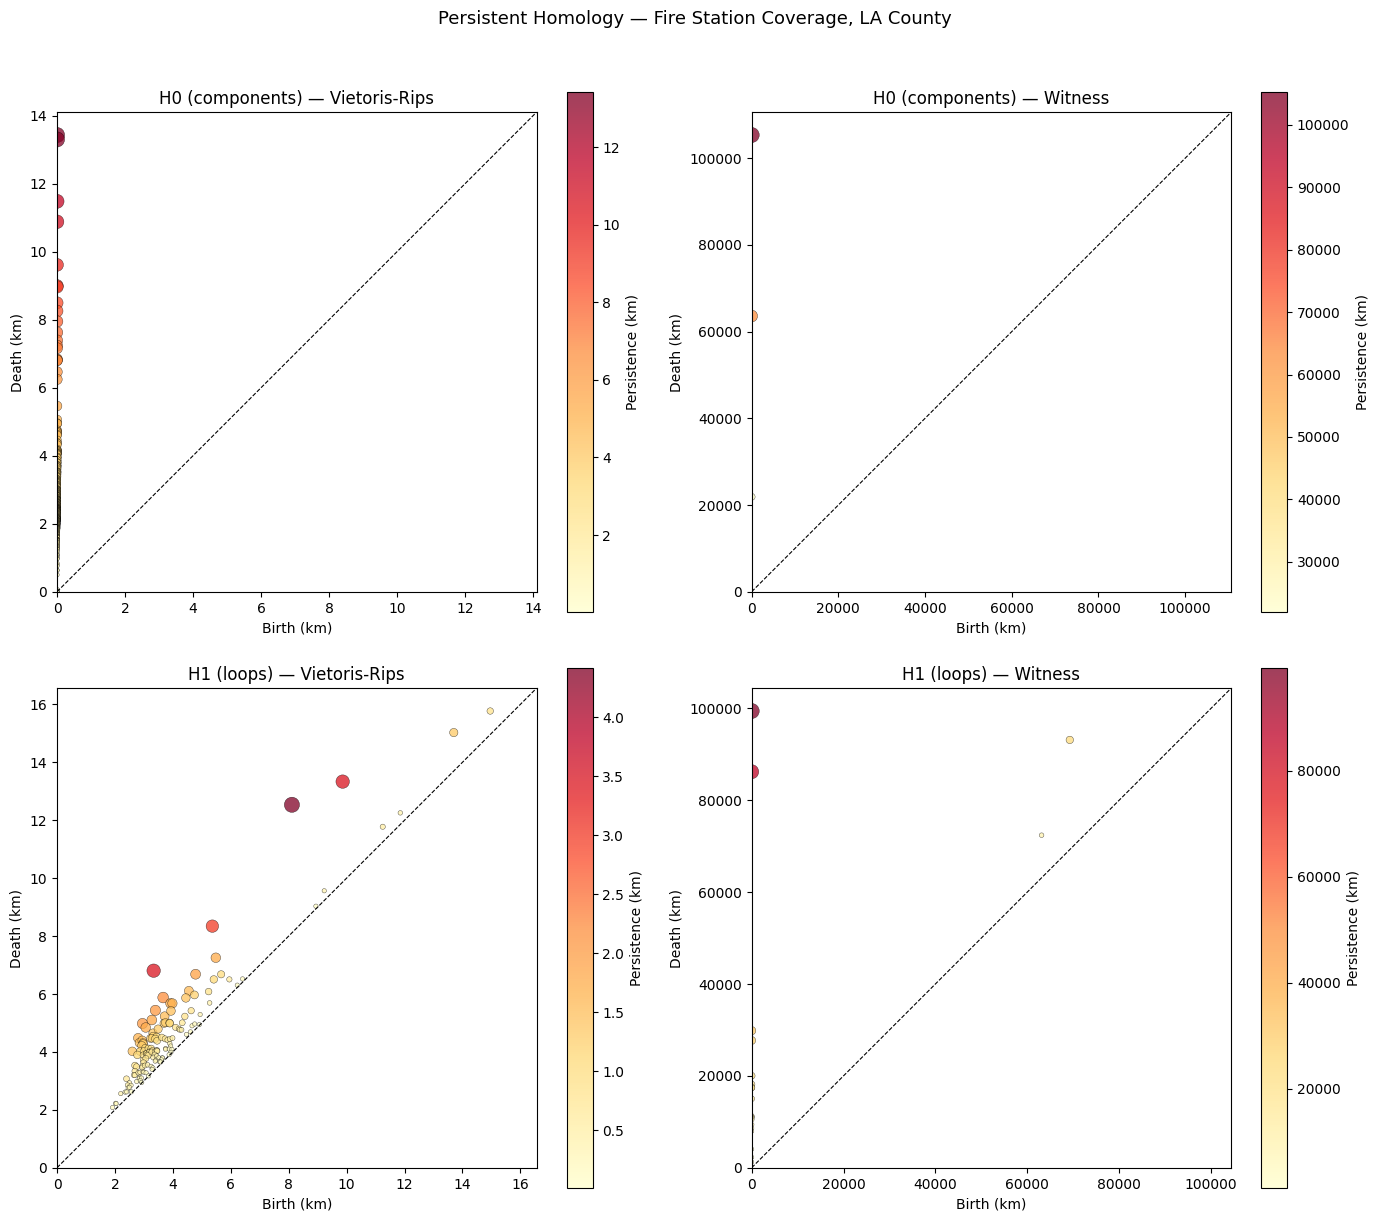

In [93]:
# ── 13a. Persistence Diagram ──
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col, (diags, title) in enumerate(zip([diag_rips, diag_wit], ["Vietoris-Rips", "Witness"])):
    for row, (dim_key, color, label) in enumerate([
        ("H0", "steelblue", "H0 (components)"),
        ("H1", "tomato",    "H1 (loops)"),
    ]):
        ax = axes[row, col]
        pairs = diags[dim_key]
        if pairs:
            arr = np.array(pairs) / 1000  # → km
            birth, death = arr[:, 0], arr[:, 1]
            persistence = death - birth

            sc = ax.scatter(birth, death,
                            c=persistence, cmap="YlOrRd",
                            s=np.clip(persistence / persistence.max() * 120, 10, 120),
                            alpha=0.75, edgecolors="k", linewidths=0.3)
            plt.colorbar(sc, ax=ax, label="Persistence (km)")

            lim = arr.max() * 1.05
            ax.plot([0, lim], [0, lim], "k--", lw=0.8)
            ax.set_xlim(0, lim); ax.set_ylim(0, lim)
            ax.set_xlabel("Birth (km)"); ax.set_ylabel("Death (km)")
            ax.set_title(f"{label} — {title}")
            ax.set_aspect("equal")
        else:
            ax.set_visible(False)

plt.suptitle("Persistent Homology — Fire Station Coverage, LA County",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../results/FireStations_persistence_diagram.png", dpi=150, bbox_inches="tight")
plt.show()


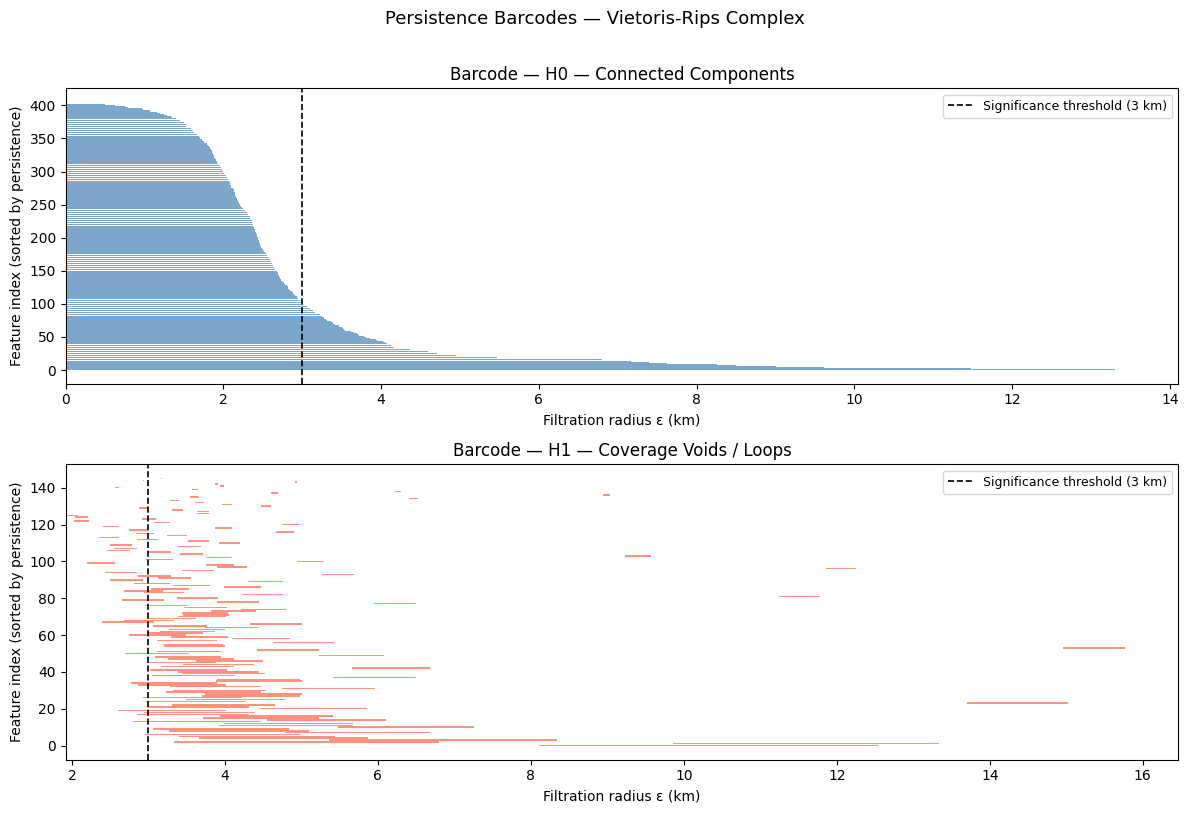

Saved: barcodes.png


In [94]:
# ── 13b. Barcode Plot ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
colors = {"H0": "steelblue", "H1": "tomato"}
labels = {"H0": "H0 — Connected Components", "H1": "H1 — Coverage Voids / Loops"}

for ax, dim_key in zip(axes, ["H0", "H1"]):
    pairs = sorted(diag_rips[dim_key], key=lambda x: x[1] - x[0], reverse=True)
    for i, (b, d) in enumerate(pairs):
        ax.barh(i, (d - b) / 1000, left=b / 1000,
                color=colors[dim_key], alpha=0.7, height=0.8)

    ax.axvline(H1_SIG_THRESHOLD_M / 1000, color="black", linestyle="--", lw=1.2,
               label=f"Significance threshold ({H1_SIG_THRESHOLD_M/1000:.0f} km)")
    ax.set_xlabel("Filtration radius ε (km)")
    ax.set_ylabel("Feature index (sorted by persistence)")
    ax.set_title(f"Barcode — {labels[dim_key]}")
    ax.legend(fontsize=9)

plt.suptitle("Persistence Barcodes — Vietoris-Rips Complex", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../../results/FireStations_barcodes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: barcodes.png")

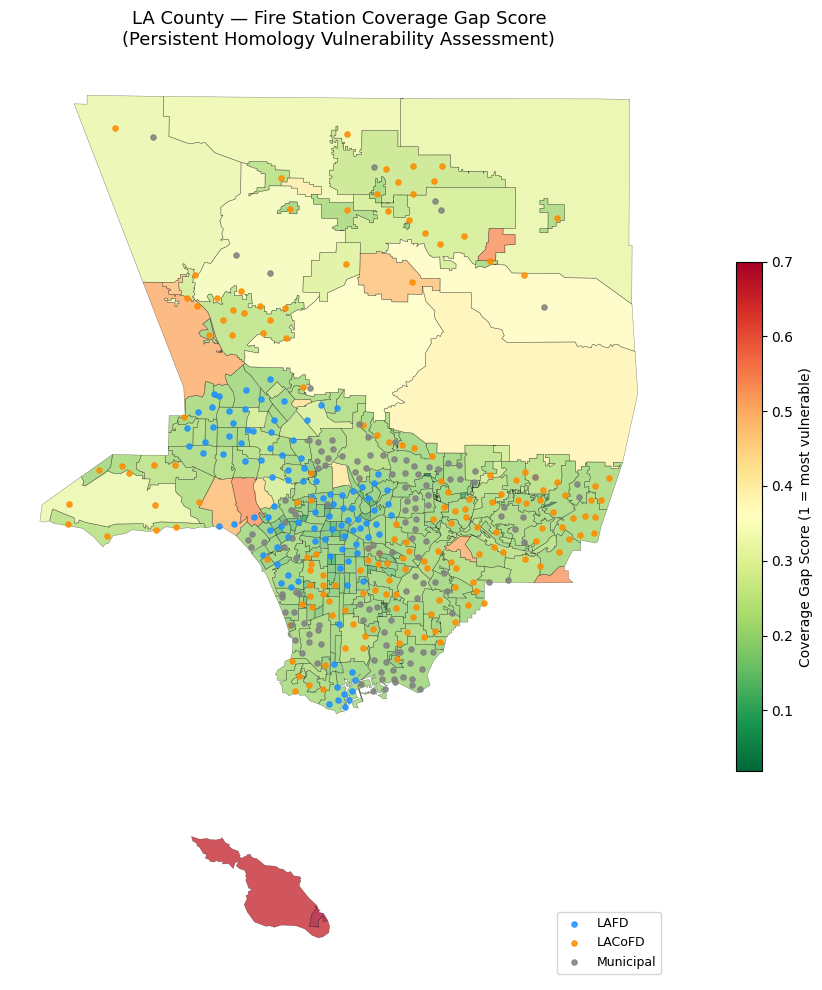

Saved: spatial_coverage.png


In [95]:
# ── 13c. Spatial Coverage Choropleth ──
fig, ax = plt.subplots(figsize=(14, 10))

merged = county_proj.merge(
    vuln_df[["neighborhood", "coverage_gap_score"]],
    left_on="name", right_on="neighborhood", how="left"
)
merged["coverage_gap_score"] = merged["coverage_gap_score"].fillna(0)

merged.plot(column="coverage_gap_score", ax=ax, cmap="RdYlGn_r",
            legend=True, alpha=0.75,
            legend_kwds={"label": "Coverage Gap Score (1 = most vulnerable)",
                         "shrink": 0.55})

dept_col = stations_proj["department"]
for mask, color, label in [
    (dept_col == "LAFD",                               "dodgerblue", "LAFD"),
    (dept_col == "LACoFD",                             "darkorange", "LACoFD"),
    (~dept_col.isin(["LAFD", "LACoFD"]),               "grey",       "Municipal"),
]:
    sub = stations_proj[mask]
    ax.scatter(sub.geometry.x, sub.geometry.y,
               c=color, s=14, alpha=0.85, label=label, zorder=5)

county_proj.boundary.plot(ax=ax, color="black", linewidth=0.3, alpha=0.5)
ax.legend(fontsize=9, loc="lower right")
ax.set_title("LA County — Fire Station Coverage Gap Score\n"
             "(Persistent Homology Vulnerability Assessment)",
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../../results/FireStations_spatial_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spatial_coverage.png")

## Step 14 — Export Results

All outputs are saved as CSV files for use in subsequent analysis stages (e.g., SVI integration, HVI correlation, Mapper algorithm).

In [96]:
# void_df.to_csv("coverage_voids.csv", index=False)
# vuln_df.to_csv("neighborhood_vulnerability.csv", index=False)
# betti_rips.to_csv("betti_numbers_rips.csv", index=False)
# betti_wit.to_csv("betti_numbers_witness.csv",  index=False)
# stats_all.to_csv("persistence_stats.csv",      index=False)

# print("Exported files:")
# print("  coverage_voids.csv             — H1 void localisation + neighborhoods")
# print("  neighborhood_vulnerability.csv — ranked vulnerability scores (272 hoods)")
# print("  betti_numbers_rips.csv         — β0, β1 at 7 operational radii (Rips)")
# print("  betti_numbers_witness.csv      — β0, β1 at 7 operational radii (Witness)")
# print("  persistence_stats.csv          — per-complex persistence statistics")
# print("  persistence_diagram.png")
# print("  barcodes.png")
# print("  spatial_coverage.png")
# print()
# print("Pipeline complete.")